# Cluster Analysis – Heart Failure Prediction Dataset
*PCA, t-SNE, UMAP, supervised UMAP, tree-based embeddings and baseline clustering on the original preprocessed feature space.*

This notebook evaluates how different dimensionality-reduction techniques influence clustering quality on the **Heart Failure Prediction Dataset**.

---
## Table of Contents
1. [Setup](#setup)  
    1.1 [Imports and Reproducibility](#imports-and-reproducibility)  
    1.2 [Data Loading](#data-loading)  
    1.3 [Feature Matrices](#feature-matrices)  
    1.4 [Feature Pruning](#feature-pruning)  

2. [Embedding Spaces](#embedding-spaces)  
    2.1 [Unsupervised Embeddings](#unsupervised-embeddings)  
    2.2 [Supervised Embeddings](#supervised-embeddings)  

3. [Cluster Analysis](#cluster-analysis)  
    3.1 [Clustering Algorithms](#clustering-algorithms)  
    3.2 [Baseline Clustering in Original Feature Space](#baseline-clustering-in-original-feature-space)  
    3.3 [Global Hyper-Parameter Search](#global-hyper-parameter-search)  
    3.4 [Detailed Evaluation of KMeans and Agglomerative](#detailed-evaluation-of-kmeans-and-agglomerative)  
    3.5 [Exploratory CLustering on Supervised Embeddings](#exploratory-clustering-on-supervised-embeddings)  
    3.6 [Leaderboards](#leaderboards)  

4. [Unsupervised Embedding Interpretation](#unsupervised-embedding-interpretation)  
    4.1 [Cluster Profiling (Unsupervised)](#cluster-profiling-unsupervised)  
    4.2 [Standardized Mean Differences (Unsupervised)](#smd-unsupervised)  
    4.3 [Target-Based Visualization (Unsupervised)](#target-visualization-unsupervised)

5. [Supervised Embedding Interpretation](#supervised-embedding-interpretation)  
    5.1 [Cluster Profiling (Supervised)](#cluster-profiling-supervised)  
    5.2 [Target-Driven Structure Analysis](#target-driven-structure-analysis)  

6. [Conclusions](#conclusions)  
    4.1 [Key Insights](#key-insights)  
    4.2 [Limitations](#limitations)  

## Setup
---

### Imports and Reproducibility

In [1]:
import os, sys, joblib, pandas as pd

sys.path.append(os.path.abspath(os.path.join('..')))

from plotly.io import show
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from scripts.dim_red.plots import plot_3d
from matplotlib import pyplot as plt
from scripts.clustering.utils import *

SEED = 42
TARGET_COL = "DEATH_EVENT"

### Data Loading

In [2]:
df_pca = joblib.load('../outputs/dim_red/df_pca.pkl')
df_tsne = joblib.load('../outputs/dim_red/df_tsne.pkl')
df_umap = joblib.load('../outputs/dim_red/df_umap.pkl')
df_mix = joblib.load('../outputs/dim_red/df_mix.pkl')
df_umap_supervised = joblib.load('../outputs/dim_red/df_umap_supervised.pkl')
df_umap_semisupervised = joblib.load('../outputs/dim_red/df_umap_semisupervised.pkl')
df_umap_xgb = joblib.load('../outputs/dim_red/df_umap_xgb.pkl')
df_preprocessed = joblib.load('../outputs/eda/df_preprocessed_balanced.pkl')

### Feature Matrices

In [3]:
X_pca  = df_pca.iloc[:, :-1]
X_tsne = df_tsne.iloc[:, :-1]
X_umap = df_umap.iloc[:, :-1]
X_mix  = df_mix.iloc[:, :-1]

X_umap_supervised     = df_umap_supervised.iloc[:, :-1]
X_umap_semisupervised = df_umap_semisupervised.iloc[:, :-1]
X_umap_xgb            = df_umap_xgb.iloc[:, :-1]

X_pre  = df_preprocessed.iloc[:, :-1]
y      = df_preprocessed.iloc[:, -1]

### Feature Pruning

In [4]:
cols_to_drop = ['high_blood_pressure', 'platelets', 'sex', 'creatinine_phosphokinase', 'anaemia', 'smoking', 'diabetes']
X_pre = X_pre.drop(columns=cols_to_drop)

X_pre.shape

(308, 5)

- Final preprocessed matrix: **308 patients × 5 features**.  
- Dropped 7 weaker and not important to keep the clustering space compact and less noisy (based on mutual information score plot from EDA).

## Embedding Spaces
---

### Unsupervised Embeddings

`PCA`, `t-SNE`, `UMAP` and the mixed embedding (`mix`) are treated as **unsupervised** representations that do not use label information.

In [5]:
embeddings_unsupervised = {
    "pca":  X_pca,
    "tsne": X_tsne,
    "umap": X_umap,
    "mix":  X_mix,
}

### Supervised Embeddings

`Supervised UMAP`, `semi-supervised UMAP` and `XGBoost leaf embeddings` are **label-informed** and encode information about `DEATH_EVENT`.

In [6]:
embeddings_supervised = {
    "umap_supervised":     X_umap_supervised,
    "umap_semisupervised": X_umap_semisupervised,
    "umap_xgb":            X_umap_xgb,
}

In [7]:
embeddings_all = {
    **embeddings_unsupervised,
    **embeddings_supervised,
}

## Cluster Analysis
---

Several precomputed embedding spaces are used:

- **Baseline**: original preprocessed feature space (`X_pre`)
- **Unsupervised embeddings**: `PCA`, `t-SNE`, `UMAP`, and a mixed embedding (`mix`)
- **Supervised embeddings**: `supervised UMAP`, `semi-supervised UMAP`, and `XGBoost leaf-based embeddings`

These representations are used as inputs to clustering algorithms to study how well different spaces reveal hidden patient structure.

### Clustering Algorithms

To evaluate how different embedding spaces support unsupervised structure, three complementary clustering algorithms are applied. These methods represent distinct theoretical paradigms and allow to compare density-based, centroid-based, and hierarchical approaches. These three algorithms complement each other and help assess how well each embedding reveals latent structure.

**DBSCAN**  
- Density-based clustering method  
- Automatically identifies noise and outliers  
- Excels when clusters have irregular or non-spherical shapes  
- Requires tuning of `eps` and `min_samples`

**KMeans**  
- Centroid-based algorithm minimizing within-cluster variance  
- Produces compact, spherical clusters  
- Requires specifying the number of clusters `k`  
- Sensitive to initialization (multiple `n_init` used for stability)

**Agglomerative Clustering**  
- Hierarchical clustering that builds clusters through iterative merging  
- Supports various linkage criteria (Ward, Complete, Average)  
- Flexible in capturing different cluster geometries  
- Does not automatically detect the number of clusters

### Baseline Clustering in Original Feature Space

#### Hyper-Parameter Search

In [ ]:
db_best_pre = gridsearch_dbscan(X=X_pre)
km_best_pre = gridsearch_kmeans_params(X_pre, ks=range(2, 8), n_inits=(25, 50))
ag_best_pre = gridsearch_agglomerative_params(X_pre, ks=range(2, 8), linkages=("ward", "complete", "average"), metrics=("euclidean", "manhattan", "cosine"))

params_db_pre = db_best_pre["params"]
params_km_pre = km_best_pre["params"]
params_ag_pre = ag_best_pre["params"]

print("DBSCAN(best on PRE):", params_db_pre)
print("KMeans(best on PRE):", params_km_pre)
print("Agglomerative(best on PRE):", params_ag_pre)

DBSCAN(best on PRE): {'eps': 0.3, 'min_samples': 3}
KMeans(best on PRE): {'n_clusters': 4, 'n_init': 50}
Agglomerative(best on PRE): {'n_clusters': 4, 'linkage': 'ward', 'metric': 'euclidean'}


- **KMeans** and **Agglomerative** both favour **4 clusters** in the original preprocessed feature space.  
- **DBSCAN** finds a reasonable density structure with `eps≈0.3`, but still needs evaluation via clustering metrics.

#### Refitting with the Best Parameters

In [9]:
db_pre = DBSCAN(**params_db_pre)
km_pre = KMeans(**params_km_pre)
ag_pre = AgglomerativeClustering(n_clusters=params_ag_pre["n_clusters"], linkage=params_ag_pre["linkage"], metric=params_ag_pre["metric"])

labels_db_pre = db_pre.fit_predict(X_pre)
labels_km_pre = km_pre.fit_predict(X_pre)
labels_ag_pre = ag_pre.fit_predict(X_pre)

scores_db_pre = show_scores("DBSCAN on PRE", X_pre, labels_db_pre, y)
scores_km_pre = show_scores("KMeans on PRE",  X_pre, labels_km_pre, y)
scores_ag_pre = show_scores("Agglomerative on PRE", X_pre, labels_ag_pre, y)

[DBSCAN on PRE] -> clusters=3, noise=2.9%, sil=0.08269899096802112, CH=5.45589071327888, DB=1.9596500146983802, ARI=0.016102190867454486, NMI=0.023963319671802562, V=0.023963319671802562
[KMeans on PRE] -> clusters=4, noise=0.0%, sil=0.24381126738332945, CH=92.69351596011816, DB=1.392891725858335, ARI=0.16128378758901413, NMI=0.17169225148109857, V=0.17169225148109857
[Agglomerative on PRE] -> clusters=4, noise=0.0%, sil=0.227154988661145, CH=86.12278283767782, DB=1.4337194729905218, ARI=0.12747242554528523, NMI=0.1462001150409351, V=0.1462001150409351


- **KMeans (4 clusters)** gives the **best overall scores** (highest silhouette / NMI) in the original feature space.  
- **Agglomerative (4 clusters)** is slightly worse but comparable.  
- **DBSCAN (3 clusters)** shows **low silhouette and low NMI** with some noise points → less suitable as a baseline.

#### Visualisation of Baseline Clusters in 3D Embeddings

In [10]:
for name, X_emb in embeddings_unsupervised.items():
    print(f"\n=== Baseline clusters visualised in {name} ===")
    plot_3d(X3d=X_emb, y=labels_db_pre, algorithm=f"DBSCAN (PRE, {name})", target_name="cluster", data_name=name, show=True)
    plot_3d(X3d=X_emb, y=labels_km_pre, algorithm=f"KMeans (PRE, {name})", target_name="cluster", data_name=name, show=True)
    plot_3d(X3d=X_emb, y=labels_ag_pre, algorithm=f"Agglomerative (PRE, {name})", target_name="cluster", data_name=name, show=True)


=== Baseline clusters visualised in pca ===



=== Baseline clusters visualised in tsne ===



=== Baseline clusters visualised in umap ===



=== Baseline clusters visualised in mix ===


- **DBSCAN** consistently fails to discover meaningful structure. Zlmost all samples fall into one large cluster, with only a few noise points across PCA, t-SNE, UMAP, and MIX. This indicates the absence of density-separated groups in the original features.

- **KMeans** and **Agglomerative** (4 clusters) provide the most stable and interpretable solutions.
  - `PCA`: clusters are present but overlapping and weakly defined.
  - `t-SNE`: clearer local grouping, but still significant overlap.
  - `UMAP`: produces distinct, more separated regions, revealing stronger latent structure.
  - `MIX`: the cleanest and most linear cluster separation; suggests an underlying gradient-like progression in patient characteristics.

- Across embeddings, KMeans and Agglomerative consistently find 3–4 moderately separable clusters, though the strength and geometry differ by embedding.

- Overall, the original feature space shows weak intrinsic cluster structure, but non-linear embeddings-especially UMAP and MIX—reveal more pronounced groupings. → This supports deeper exploration using supervised embeddings, where outcome information can sharpen cluster boundaries.

### Global Hyper-Parameter Search

For each embedding space (PCA, t-SNE, UMAP, MIX, supervised UMAP variants), a full hyper-parameter search using three clustering algorithms is performed:

1. **DBSCAN**  
   - estimates density structure using a k-distance plot  
   - parameters tuned automatically via `gridsearch_dbscan`

2. **KMeans**  
   - evaluated across a range of cluster counts `k=2..8`  
   - multiple initializations (`n_inits`) used for robustness

3. **Agglomerative Clustering**  
   - searched over several linkage strategies (Ward, Complete, Average)  
   - and multiple distance metrics (Euclidean, Manhattan, Cosine)

This loop produces the best parameters and performance metrics for each (embedding × algorithm) combination, which are later used in the leaderboards.


=== Embedding: PCA ===


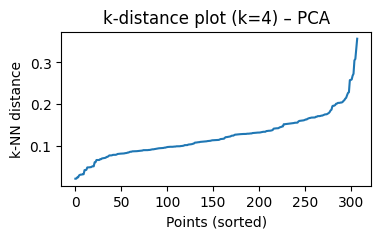

[DBSCAN] best params: {'eps': 0.2, 'min_samples': 5}
[KMeans] best params: {'n_clusters': 4, 'n_init': 20}
[Agglomerative] best params: {'n_clusters': 7, 'linkage': 'ward', 'metric': 'euclidean'}

=== Embedding: TSNE ===


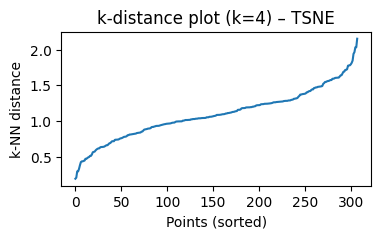

[DBSCAN] best params: {'eps': 1.2, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 5, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 5, 'linkage': 'complete', 'metric': 'euclidean'}

=== Embedding: UMAP ===


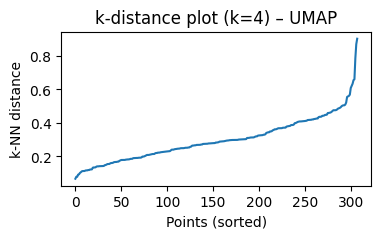

[DBSCAN] best params: {'eps': 0.8, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 6, 'n_init': 20}
[Agglomerative] best params: {'n_clusters': 7, 'linkage': 'average', 'metric': 'euclidean'}

=== Embedding: MIX ===


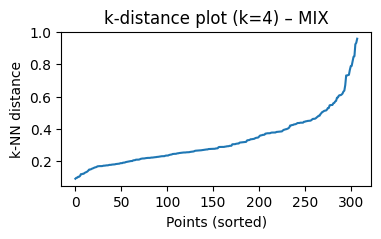

[DBSCAN] best params: {'eps': 0.5, 'min_samples': 5}
[KMeans] best params: {'n_clusters': 2, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 3, 'linkage': 'complete', 'metric': 'manhattan'}

=== Embedding: UMAP_SUPERVISED ===


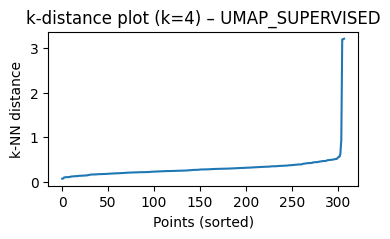

[DBSCAN] best params: {'eps': 0.8, 'min_samples': 5}
[KMeans] best params: {'n_clusters': 2, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}

=== Embedding: UMAP_SEMISUPERVISED ===


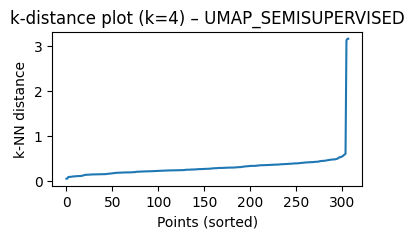

[DBSCAN] best params: {'eps': 0.8, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 2, 'n_init': 10}
[Agglomerative] best params: {'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}

=== Embedding: UMAP_XGB ===


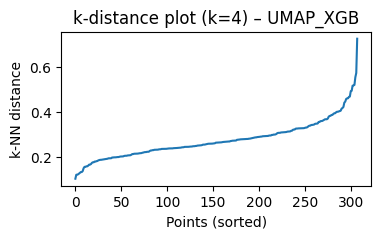

[DBSCAN] best params: {'eps': 0.8, 'min_samples': 3}
[KMeans] best params: {'n_clusters': 3, 'n_init': 20}
[Agglomerative] best params: {'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'}


In [11]:
dbscan_best = {}
kmeans_best = {}
agglom_best = {}

for name, X in embeddings_all.items():
    print(f"\n=== Embedding: {name.upper()} ===")
    
    # --- 1) DBSCAN ---
    kd = k_distance_plot(X=X, k=4)
    plt.figure(figsize=(4, 2))
    plt.plot(kd)
    plt.title(f"k-distance plot (k=4) – {name.upper()}")
    plt.xlabel("Points (sorted)")
    plt.ylabel("k-NN distance")
    plt.show()
    
    db_best = gridsearch_dbscan(X=X)
    dbscan_best[name] = db_best
    print("[DBSCAN] best params:", db_best["params"])
    
    # --- 2) KMeans ---
    km_best = gridsearch_kmeans_params(X, ks=range(2, 8), n_inits=(10, 20),)
    kmeans_best[name] = km_best
    km_params  = km_best.get("params", km_best)
    print("[KMeans] best params:", km_params)
    
    # --- 3) Agglomerative ---
    ag_best = gridsearch_agglomerative_params(
        X,
        ks=range(2, 8),
        linkages=("ward", "complete", "average"),
        metrics=("euclidean", "manhattan", "cosine"),
    )
    agglom_best[name] = ag_best
    ag_params  = ag_best.get("params", ag_best)
    print("[Agglomerative] best params:", ag_params)


- For **unsupervised embeddings (PCA, t-SNE, UMAP, MIX)**:
  - Best **KMeans / Agglomerative** solutions use between **2 and 7 clusters**  
    - **UMAP**: prefers **6–7 clusters**  
    - **MIX**: prefers **2–3 clusters**
  - **DBSCAN** needs **moderate `eps` (0.5–0.8)** and **low `min_samples` (3–5)** to form non-trivial clusters.
- For **supervised embeddings (UMAP_SUPERVISED / UMAP_SEMISUPERVISED / UMAP_XGB)**:
  - Best **KMeans / Agglomerative** consistently pick **2 clusters**.
  - **DBSCAN** also works with `eps = 0.8` and `min_samples = 3–5`, reinforcing a **very compact 2-cluster structure** aligned with the outcome.

### Detailed Evaluation of KMeans and Agglomerative

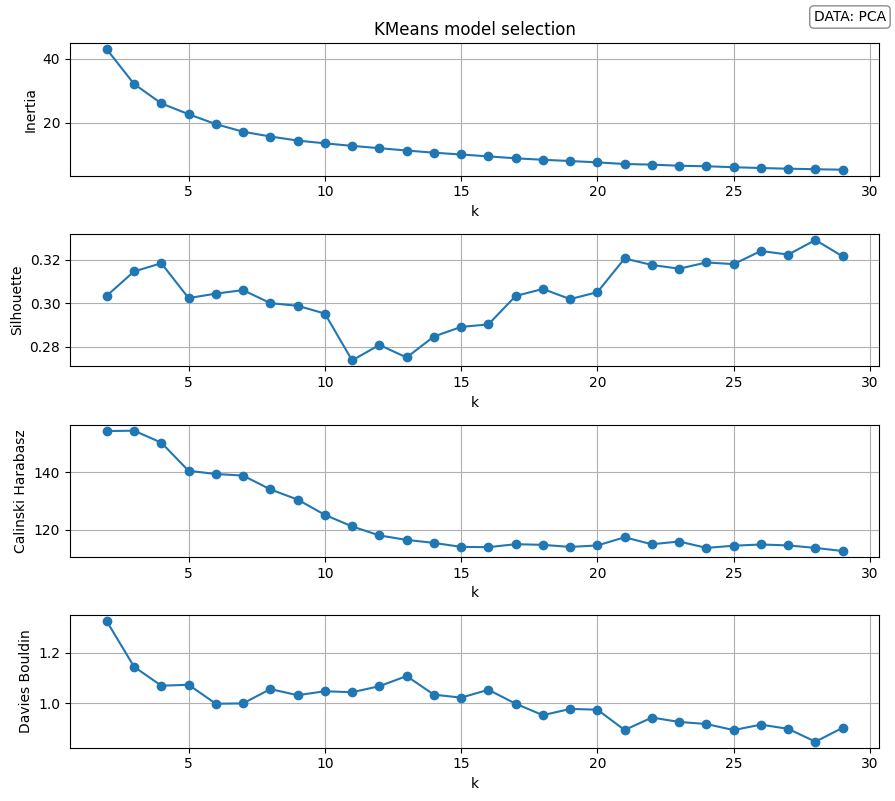

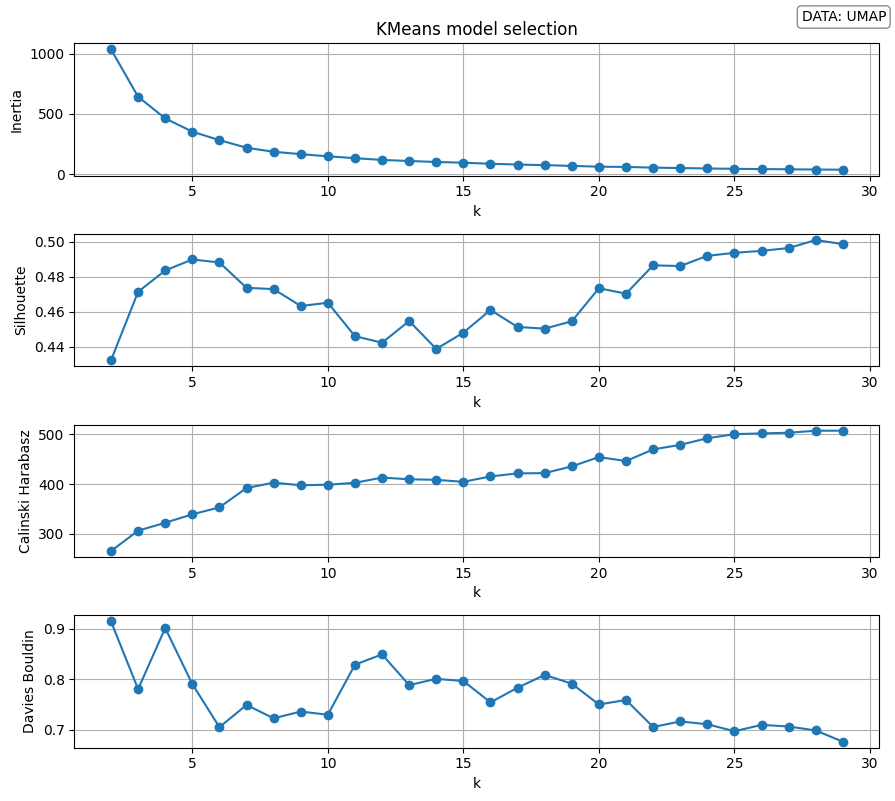

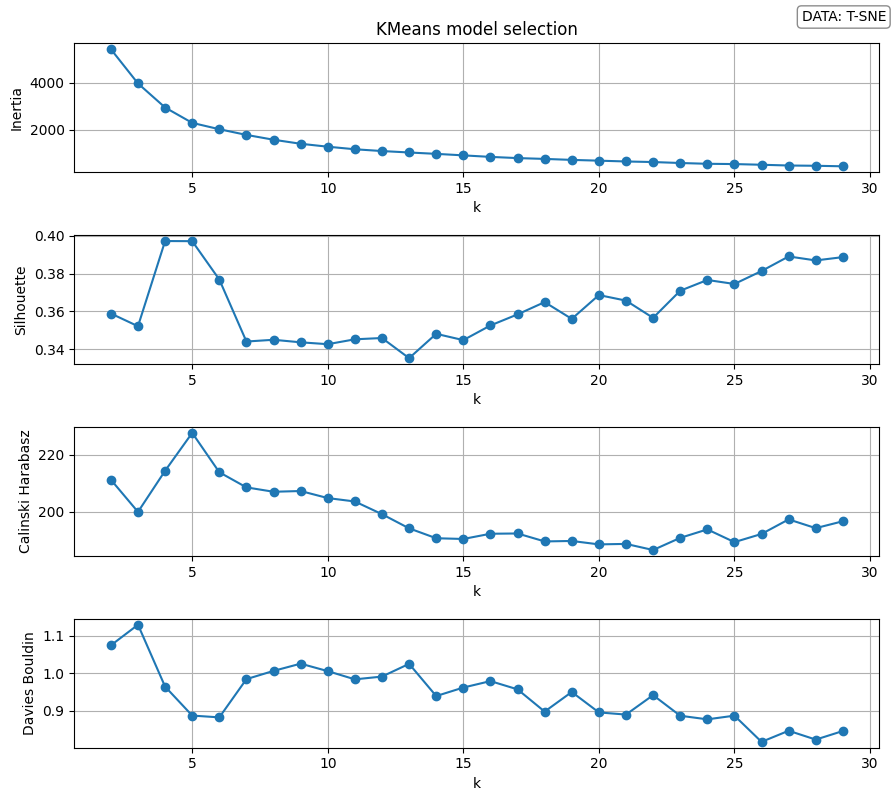

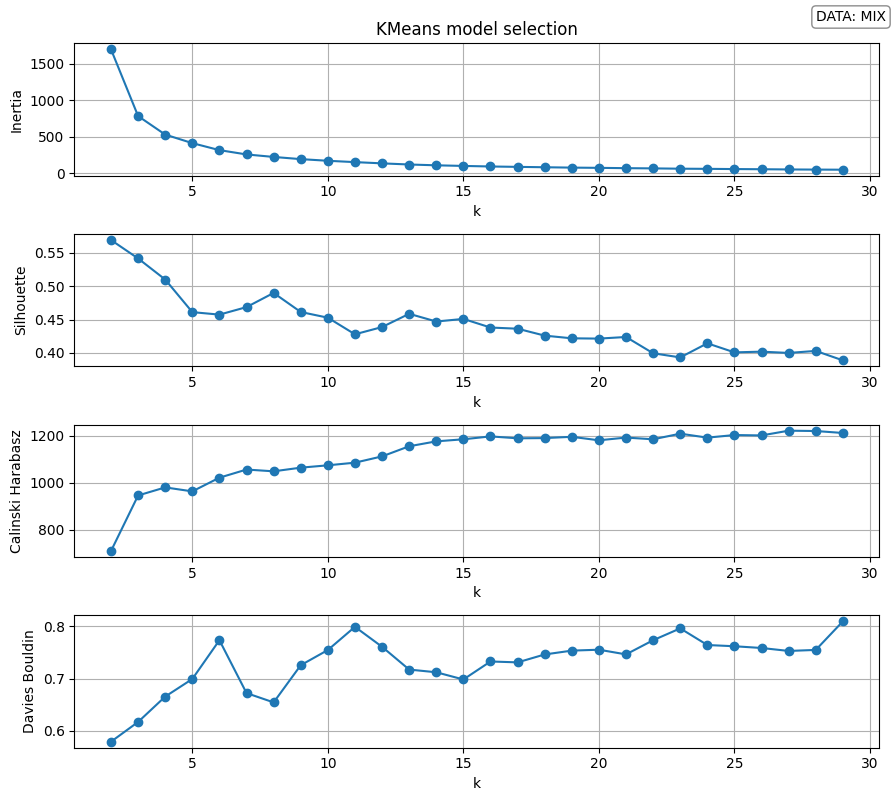


KMeans on PCA
{'inertia': 29, 'silhouette': 28, 'calinski_harabasz': 3, 'davies_bouldin': 28}

KMeans on UMAP
{'inertia': 29, 'silhouette': 28, 'calinski_harabasz': 29, 'davies_bouldin': 29}

KMeans on T-SNE
{'inertia': 29, 'silhouette': 4, 'calinski_harabasz': 5, 'davies_bouldin': 26}

KMeans on MIX
{'inertia': 29, 'silhouette': 2, 'calinski_harabasz': 27, 'davies_bouldin': 2}


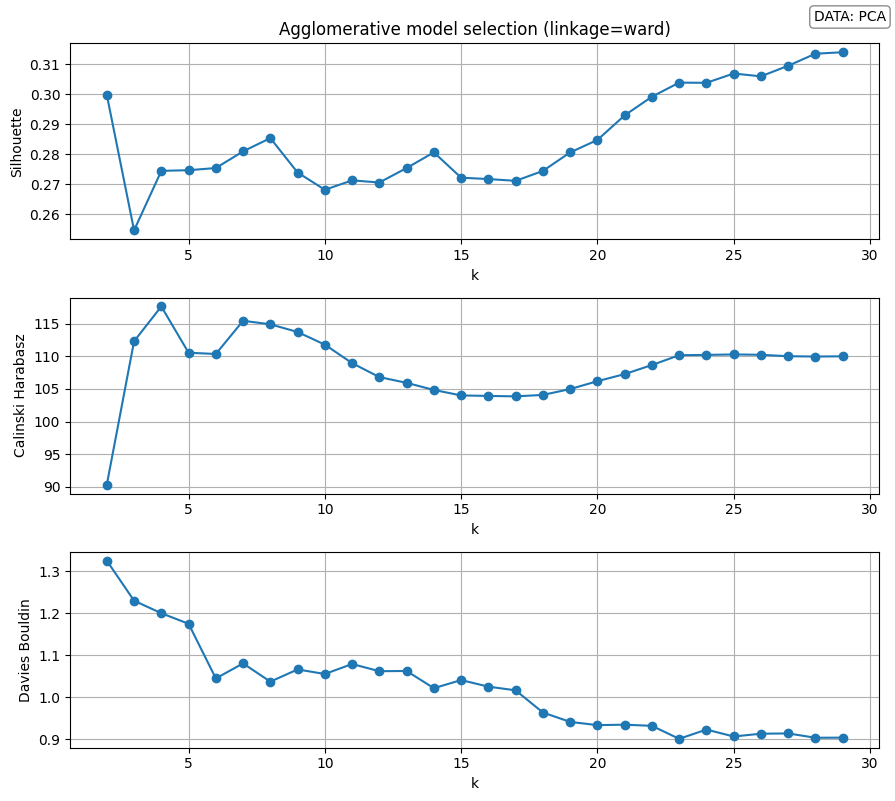

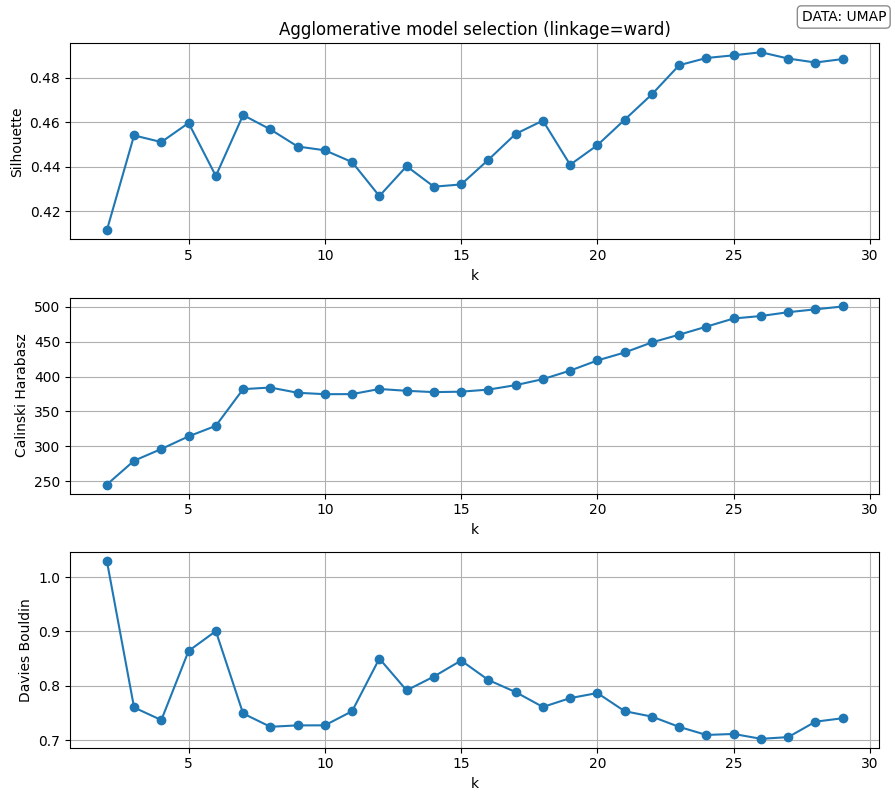

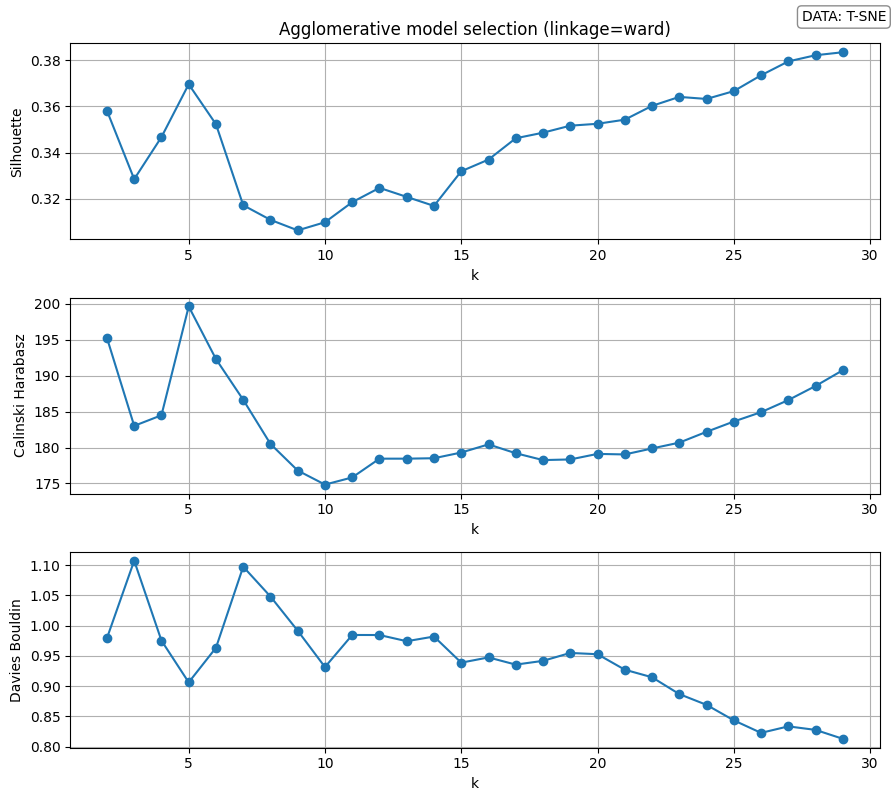

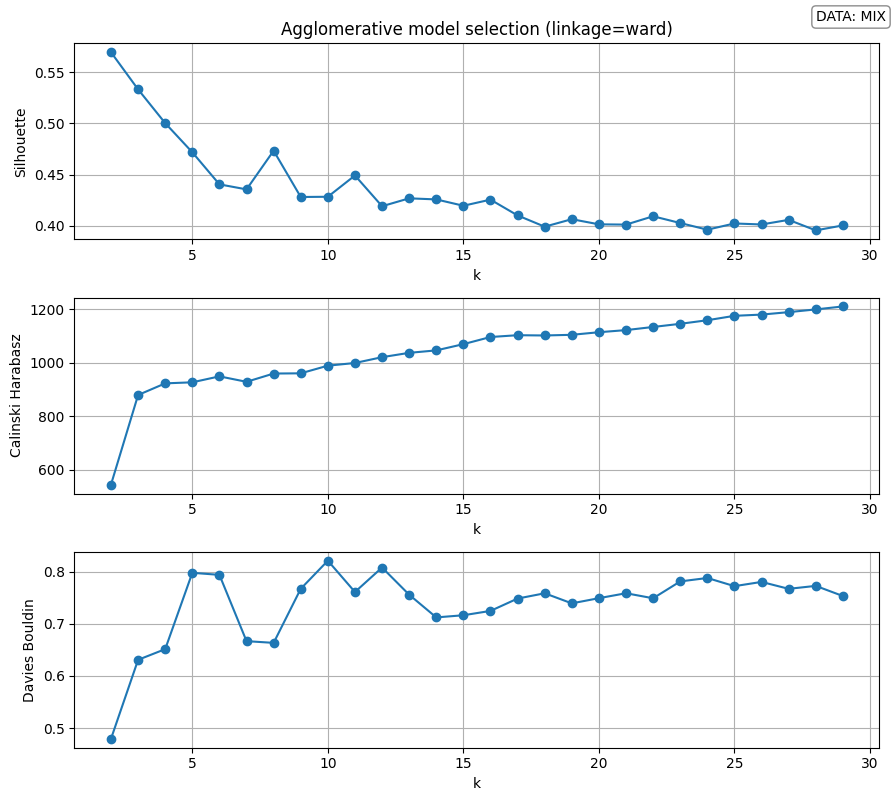


Agglomerative on PCA
{'silhouette': 29, 'calinski_harabasz': 4, 'davies_bouldin': 23}

Agglomerative on UMAP
{'silhouette': 26, 'calinski_harabasz': 29, 'davies_bouldin': 26}

Agglomerative on T-SNE
{'silhouette': 29, 'calinski_harabasz': 5, 'davies_bouldin': 29}

Agglomerative on MIX
{'silhouette': 2, 'calinski_harabasz': 29, 'davies_bouldin': 2}


In [12]:
# KMEANS
kmeans_results = {
    'pca':  select_k_kmeans(X_pca,  k_range=range(2, 30), n_init=50, data_name="PCA"),
    'umap': select_k_kmeans(X_umap, k_range=range(2, 30), n_init=50, data_name="UMAP"),
    't-SNE':select_k_kmeans(X_tsne, k_range=range(2, 30), n_init=50, data_name="t-SNE"),
    'MIX':  select_k_kmeans(X_mix,  k_range=range(2, 30), n_init=50, data_name="MIX"),
}

for name, res in kmeans_results.items():
    print(f"\nKMeans on {name.upper()}")
    print(res.best_by_metric)
    
# AGGLOMERATIVE
agg_results = {
    'pca':  select_k_agglomerative(X_pca,  k_range=range(2, 30), data_name="PCA"),
    'umap': select_k_agglomerative(X_umap, k_range=range(2, 30), data_name="UMAP"),
    't-SNE':select_k_agglomerative(X_tsne, k_range=range(2, 30), data_name="t-SNE"),
    'MIX':  select_k_agglomerative(X_mix,  k_range=range(2, 30), data_name="MIX"),
}

for name, res in agg_results.items():
    print(f"\nAgglomerative on {name.upper()}")
    print(res.best_by_metric)

- Internal validation often **pushes for high k (e.g. k≈20–30)**, especially for inertia / Calinski-Harabasz.  
- To keep clusters **interpretable**, we treat these metrics as **guidance only** and later focus on **small k (≈2–7)** chosen via the global search + visual inspection.

### Exploratory Clustering on Supervised Embeddings

The following section applies clustering to:

- **Supervised UMAP**, **semi-supervised UMAP**, and **XGBoost leaf + UMAP**,  
  which are **label-informed** embeddings (they explicitly encode information about `DEATH_EVENT`).


Because supervised embeddings incorporate outcome information, clusters formed in these spaces **cannot be interpreted** as purely data-driven clinical subgroups. Instead, they reflect how a model organizes patients when the target label is available.

**Methodological distinction:**
- Unsupervised clusters → natural patient subgroups (data-driven)
- Supervised clusters → outcome-informed risk strata (model-driven)

Therefore, the results in this section are used primarily for **visualization, exploratory inspection, and understanding model behavior**, not for deriving final clinical conclusions.

In [52]:
rows_ex = []

exploratory_params_km = {
    "umap_supervised":     {"k": 2, "n_init": 10},
    "umap_semisupervised": {"k": 2, "n_init": 10},
    "umap_xgb":            {"k": 3, "n_init": 20},
}

for name, X in embeddings_supervised.items():
    p = exploratory_params_km[name]

    km = KMeans(n_clusters=p["k"], n_init=p["n_init"])
    labels = km.fit_predict(X)

    fig = plot_3d(X3d=X, y=labels, algorithm=f"[EXPLORATORY] KMeans on {name}", target_name="cluster", data_name=name.upper())
    show(fig)

Supervised embeddings reveal much stronger and clinically meaningful structure than unsupervised ones. They consistently produce 2–3 fully separated and interpretable clusters.

### Leaderboards

#### Unsupervised Embeddings

In [14]:
board_unsupervised = build_global_leaderboard(embeddings_unsupervised)
ordered_unsupervised = rank_leaderboard(board_unsupervised)

rows_unsup = []
for i, r in enumerate(ordered_unsupervised, 1):
    m = r["metrics"]
    rows_unsup.append({
        "Embedding": r["emb"].upper(),
        "Algorithm": r["algo"].upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4),
    })

df_leader_unsup = pd.DataFrame(rows_unsup)
df_leader_unsup.style    .background_gradient(subset=["Silhouette"], cmap="Greens")    .background_gradient(subset=["Calinski-Harabasz"], cmap="Blues")    .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})


,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,MIX,KMEANS,"{'n_clusters': 2, 'n_init': 10}",2,0.5692,709.37,0.5795
1,MIX,AGGLOMERATIVE,"{'n_clusters': 3, 'linkage': 'complete', 'metric': 'manhattan'}",3,0.5423,945.24,0.6185
2,UMAP,KMEANS,"{'n_clusters': 5, 'n_init': 10}",5,0.4898,339.29,0.7905
3,UMAP,AGGLOMERATIVE,"{'n_clusters': 4, 'linkage': 'complete', 'metric': 'euclidean'}",4,0.4650,305.16,0.7591
4,UMAP,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",4,0.4232,230.24,0.7029
5,TSNE,KMEANS,"{'n_clusters': 5, 'n_init': 10}",5,0.3972,227.57,0.8871
6,TSNE,AGGLOMERATIVE,"{'n_clusters': 5, 'linkage': 'complete', 'metric': 'euclidean'}",5,0.3733,204.92,0.8816
7,PCA,KMEANS,"{'n_clusters': 4, 'n_init': 25}",4,0.3176,150.30,1.0678
8,PCA,AGGLOMERATIVE,"{'n_clusters': 4, 'linkage': 'ward', 'metric': 'euclidean'}",4,0.2744,117.61,1.1999
9,PCA,DBSCAN,"{'eps': 0.2, 'min_samples': 5}",2,0.2132,8.68,3.4476


- **MIX embedding dominate**s the ranking:
  - MIX + KMeans (2 clusters) achieves the highest silhouette (0.5692) and strong Calinski–Harabasz, indicating clear, compact, and well-separated groups.
  - MIX + Agglomerative (3 clusters) is a close second, confirming the stability of the structure revealed by MIX.
 
- **UMAP embedding** consistently outperforms PCA and t-SNE:
Both KMeans and Agglomerative on UMAP appear in the top 4 results, showing that UMAP exposes meaningful, non-linear latent structure in the original data.

- **t-SNE and PCA** produce weaker separation:
  - Silhouette values drop to ~0.31 or lower.
  - DBSCAN performs poorly, producing high DB values and many small/noise clusters.

- **DBSCAN is not suitable** for this dataset in unsupervised settings:
  - Across embeddings, DBSCAN yields either very low silhouette or excessive numbers of micro-clusters, reflecting no true density-based structure.

Overall, the best-performing cluster structures emerge from non-linear embeddings, especially **MIX** and **UMAP**, suggesting that these transformations capture the most informative geometry of the patient space.

#### Supervised Embedings

In [15]:
board_supervised = build_global_leaderboard(embeddings_supervised)
ordered_supervised = rank_leaderboard(board_supervised)

rows_sup = []
for i, r in enumerate(ordered_supervised, 1):
    m = r["metrics"]
    rows_sup.append({
        "Embedding": r["emb"].upper(),
        "Algorithm": r["algo"].upper(),
        "Params": str(r["params"]),
        "Clusters": m.get("n_clusters"),
        "Silhouette": round(m.get("silhouette"), 4),
        "Calinski-Harabasz": round(m.get("calinski_harabasz"), 2),
        "Davies-Bouldin": round(m.get("davies_bouldin"), 4),
    })

df_leader_sup = pd.DataFrame(rows_sup)
df_leader_sup.style    .background_gradient(subset=["Silhouette"], cmap="Greens")    .background_gradient(subset=["Calinski-Harabasz"], cmap="Blues")    .background_gradient(subset=["Davies-Bouldin"], cmap="Reds_r")    .format({"Silhouette": "{:.4f}", "Calinski-Harabasz": "{:.2f}", "Davies-Bouldin": "{:.4f}"})


,Embedding,Algorithm,Params,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,UMAP_SUPERVISED,KMEANS,"{'n_clusters': 2, 'n_init': 10}",2,0.9455,36830.28,0.0824
1,UMAP_SUPERVISED,AGGLOMERATIVE,"{'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}",2,0.9455,36830.28,0.0824
2,UMAP_SUPERVISED,DBSCAN,"{'eps': 0.8, 'min_samples': 5}",2,0.8780,8389.88,1.1177
3,UMAP_SEMISUPERVISED,KMEANS,"{'n_clusters': 2, 'n_init': 10}",2,0.8777,7439.99,0.1874
4,UMAP_SEMISUPERVISED,AGGLOMERATIVE,"{'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}",2,0.8777,7439.99,0.1874
5,UMAP_XGB,KMEANS,"{'n_clusters': 3, 'n_init': 25}",3,0.7484,3247.07,0.3577
6,UMAP_XGB,AGGLOMERATIVE,"{'n_clusters': 3, 'linkage': 'ward', 'metric': 'euclidean'}",3,0.7484,3247.07,0.3577
7,UMAP_XGB,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",3,0.7484,3247.07,0.3577
8,UMAP_SEMISUPERVISED,DBSCAN,"{'eps': 0.8, 'min_samples': 3}",3,0.6155,3909.98,0.3323


- **UMAP_SUPERVISED** is the strongest performer, with both KMeans and Agglomerative achieving the highest silhouette scores (≈0.945) and excellent Calinski–Harabasz values, indicating exceptionally compact and well-separated clusters.

- All top-performing models use exactly **2 clusters**, showing that supervised embeddings consistently reveal a natural binary structure aligned with the outcome (low-risk vs. high-risk patient groups).

- **DBSCAN** improves compared to unsupervised embeddings, achieving a strong silhouette (0.878) in UMAP_SUPERVISED, but still ranks below KMeans/Agglomerative due to less stable cluster compactness.

- **UMAP_SEMISUPERVISED** also performs very well, matching the top silhouette values (~0.878) and confirming the robustness of the 2-cluster structure even with partial supervision.

- **UMAP_XGB** identifies 3-cluster solutions with lower silhouette (~0.748), suggesting a more nuanced, multi-level phenotype separation, but still significantly better than any unsupervised embedding.

Overall, supervised embeddings dramatically enhance cluster separation, revealing a **clear, interpretable risk-related patient structure** that is not visible in the original or purely unsupervised embeddings.

## Unsupervised Embedding Interpretation
---

### Cluster Profiling (Unsupervised)

Cluster profiles are analysed using Standardized Mean Differences (SMD) for the top-performing unsupervised clustering solutions. This helps to understand how clinical features differ across discovered clusters and whether they correspond to distinct patient phenotypes.

In [16]:
topK = 3
X_orig = X_pre.copy()

interpretation = {}

for i, r in enumerate(ordered_unsupervised[:topK], 1):
    labels = r["labels"]
    algo   = r["algo"].upper()
    emb    = r["emb"].upper()
    params = r["params"]
    m      = r["metrics"]

    prof, overall = cluster_profile(X_orig, labels)
    interpretation[(emb, algo, i)] = {"profile": prof, "overall": overall, "params": params, "metrics": m}

    print(f"\n=== {i}. {emb} – {algo} ===\nparams={params}")
    display(prof.style.format("{:.3f}"))



=== 1. MIX – KMEANS ===
params={'n_clusters': 2, 'n_init': 10}



=== 2. MIX – AGGLOMERATIVE ===
params={'n_clusters': 3, 'linkage': 'complete', 'metric': 'manhattan'}



=== 3. UMAP – KMEANS ===
params={'n_clusters': 5, 'n_init': 10}


MIX + KMeans (2 clusters)
- Clear **bipartition** of patients:
  - **Cluster 0** shows **older age**, **lower ejection fraction**, **higher serum creatinine**, and **lower sodium** → consistent with a **higher-risk profile**.
  - **Cluster 1** shows **younger age**, **slightly better cardiac function**, and **lower creatinine** → **lower-risk profile**.
- Differences between clusters are **consistent across all features**, indicating a strong underlying severity gradient.

MIX + Agglomerative (3 clusters)
- Three distinct phenotypes emerge:
  - **Cluster 1** (middle group) shows **worst ejection fraction** and **highest creatinine**, suggesting a **highest-risk subgroup**.
  - **Cluster 0** appears intermediate: moderately impaired EF and creatinine.
  - **Cluster 2** shows comparatively **better cardiac and renal markers** → **lowest-risk subgroup**.
- The MIX embedding cleanly separates clusters along clinical severity.

UMAP + KMeans (5 clusters)
- Produces **finer-grained stratification**:
  - **Cluster 0**: high creatinine + low sodium → **renal-related risk**.
  - **Cluster 1**: very high ejection fraction and normal labs → **compensated/low-risk**.
  - **Cluster 3**: low EF and moderately elevated creatinine → **cardiac-driven risk**.
  - **Cluster 2 & 4**: intermediate values, representing **mixed or transitional subgroups**.
- UMAP uncovers **multiple distinct severity patterns**, rather than a single linear gradient.

### Standardized Mean Differences (Unsupervised)

In [17]:
top_smd_tables = {}

for i, r in enumerate(ordered_unsupervised[:topK], 1):
    smd_df = compute_smds(X_orig, r["labels"])
    top_smd_tables[(i, r["emb"].upper(), r["algo"].upper())] = smd_df

for rank in range(1, topK + 1):
    entry = ordered_unsupervised[rank - 1]
    key = (rank, entry["emb"].upper(), entry["algo"].upper())
    smd_df = top_smd_tables[key]
    tbl = top_union_smd_table(smd_df, top_n=8, feature_order="max")
    display(tbl.style.format("{:.3f}").set_caption(f"|SMD| cluster — [{rank}] {key[1]} – {key[2]}"))


,Cluster 0,Cluster 1
Feature,,
time,0.704,0.977
serum_creatinine,0.272,0.378
age,0.151,0.210
serum_sodium,0.081,0.112
ejection_fraction,0.003,0.004


,Cluster 0,Cluster 1,Cluster 2
Feature,,,
time,0.030,0.924,1.241
serum_creatinine,0.237,0.606,0.462
age,0.312,0.562,0.303
ejection_fraction,0.322,0.294,0.060
serum_sodium,0.123,0.004,0.173


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
Feature,,,,,
serum_creatinine,1.568,0.308,0.415,0.702,0.226
ejection_fraction,0.368,1.536,0.082,0.127,0.681
time,0.458,0.247,1.211,0.361,1.124
serum_sodium,0.786,0.187,0.234,0.044,0.557
age,0.220,0.454,0.252,0.492,0.487


MIX + KMeans (2 clusters)
- Moderate-to-large SMDs across **time**, **serum creatinine**, and **age** indicate a **strong separation** between the two clusters.
- Extremely small SMDs for **ejection fraction** and **sodium** suggest these variables contribute less to MIX–KMeans separation.
- Overall pattern: clusters differ mainly in **renal function**, **disease duration**, and **age**, forming a clear low-risk vs higher-risk split.

MIX + Agglomerative (3 clusters)
- Cluster 1 shows consistently **large SMDs across all key variables**, marking it as a **distinct high-risk group**.
- Cluster 0 and Cluster 2 show more moderate differences, but still diverge in **creatinine**, **age**, and **ejection fraction**.
- MIX Agglomerative reveals a **three-tier risk structure** with one dominant high-risk phenotype and two intermediate/low-risk groups.

UMAP + KMeans (5 clusters)
- Very large SMDs in **serum creatinine** and **serum sodium** show strong separation driven by **renal function and electrolyte levels**.
- **Ejection fraction** also contributes meaningfully, especially separating Cluster 1 (very high EF) from other groups.
- **Time** varies significantly across clusters, indicating different disease progression stages.
- UMAP produces the **finest-grained stratification**, revealing **multiple distinct clinical subtypes** rather than a simple low/high-risk split.

#### SMD plots


=== [1] MIX – KMEANS ===


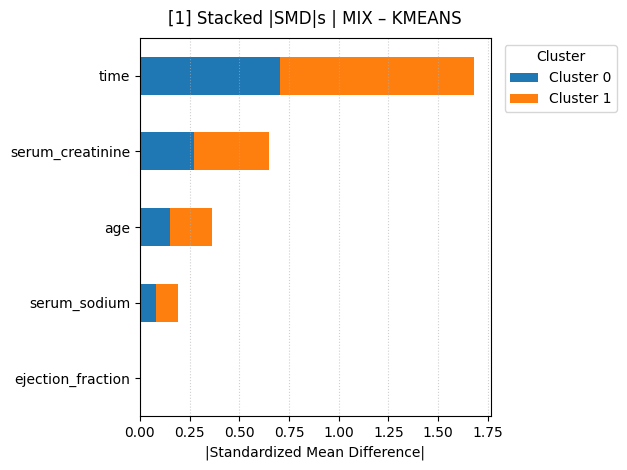

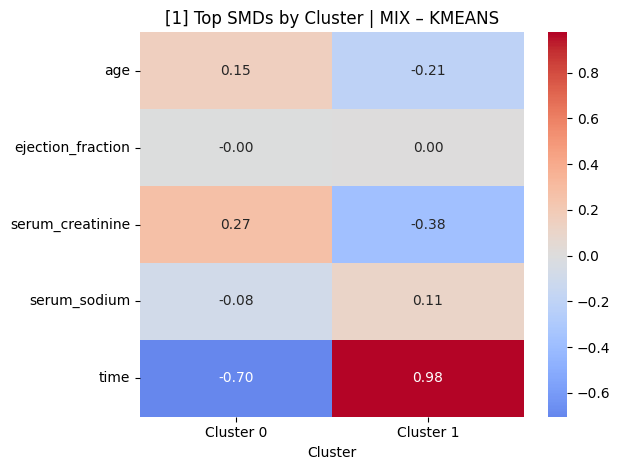


=== [2] MIX – AGGLOMERATIVE ===


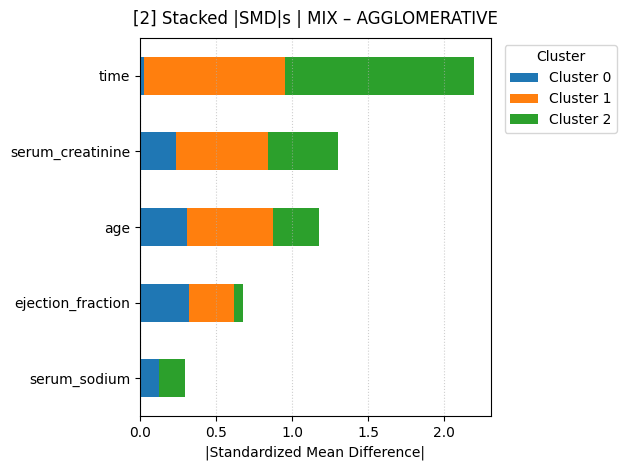

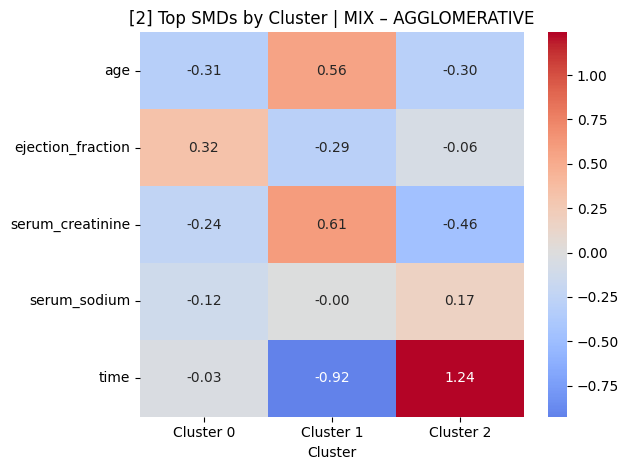


=== [3] UMAP – KMEANS ===


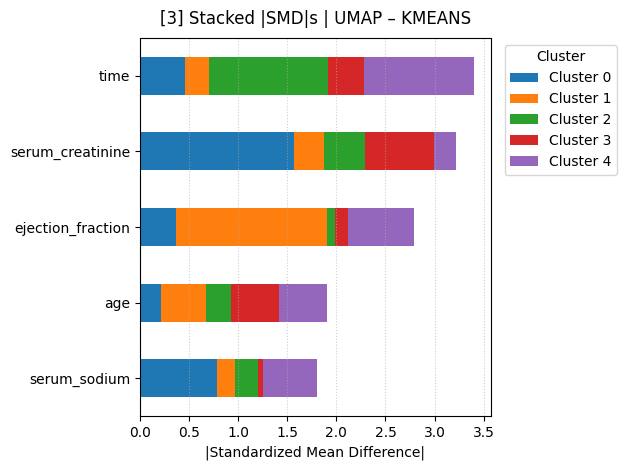

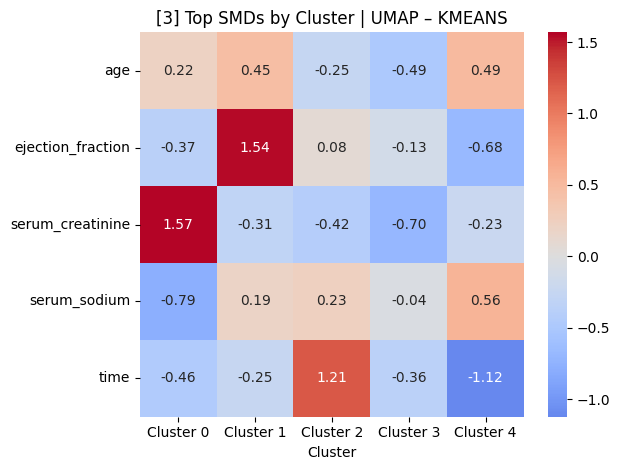

In [18]:
for rank in range(1, topK + 1):
    entry = ordered_unsupervised[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"].upper()
    key    = (rank, emb, algo)
    smd_df = top_smd_tables[key]

    print(f"\n=== [{rank}] {emb} – {algo} ===")
    plot_smd_stacked_bars(smd_df=smd_df, rank=rank, emb=emb, algo=algo)
    plot_smd_heatmap(smd_df=smd_df, rank=rank, emb=emb, algo=algo)

MIX – KMEANS (2 clusters) 
- Largest SMD is for **time**, indicating strong separation based on follow-up duration (Cluster 1 much higher).  
- Moderate differences in **serum creatinine** and **age** suggest renal function and age structure drive the cluster split.  
- **Ejection fraction** and **sodium** show minimal SMD, meaning they do not significantly distinguish these two clusters.  
- Overall: MIX–KMeans captures a **clear two-group gradient**, primarily driven by **disease progression and renal markers**.

MIX – AGGLOMERATIVE (3 clusters)
- Very large SMD on **time** for Cluster 2 indicates a **severe/high-progression subgroup**.  
- Cluster 1 shows consistently high SMDs for **creatinine** and **age**, marking it as a **renal-risk + older** subgroup.  
- Ejection fraction differs moderately across clusters, with Cluster 0 showing better cardiac function.  
- Overall: MIX–Agglomerative reveals **three distinct phenotypes**:  
  - **Cluster 0:** moderate/low risk  
  - **Cluster 1:** renal-driven high risk  
  - **Cluster 2:** longest follow-up, advanced disease severity  

UMAP – KMEANS (5 clusters)
- Very large SMDs for **serum creatinine** and **ejection fraction** highlight strong separation based on **kidney function** and **cardiac output**.  
- **Time** shows large SMD variability (e.g., Cluster 2 very high), indicating **different disease stages** across clusters.  
- **Sodium** differences are notable, with Cluster 4 showing higher sodium (potentially more stable patients).  
- Age also varies substantially, separating older vs. younger phenotypes.  
- Overall: UMAP–KMeans uncovers **fine-grained, multi-dimensional subtypes**, not just low/high-risk, including:  
  - clusters dominated by **renal dysfunction**,  
  - clusters dominated by **cardiac impairment**,  
  - and a cluster with **long disease duration**.

### Target-Based Visualization (Unsupervised)

In [38]:
for rank in range(1, topK + 1):
    entry = ordered_unsupervised[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"]
    labels = entry["labels"]
    params = entry["params"]

    plot_clusters_target_3d(
        embeddings_unsupervised[emb],
        labels,
        y,
        title=f"[{rank}] {emb.upper()} – {algo}  params={params} | Clusters vs {TARGET_COL}"
    )

- Unsupervised embeddings do capture mortality-related patterns, even without using the outcome label.

- However, clusters are not clean risk groups; they instead reflect underlying physiological heterogeneity (age, EF, creatinine, sodium, time).

- Some clusters align strongly with higher mortality, driven by known risk markers — providing biological plausibility.

- But because the embeddings and clustering are unsupervised, these patterns emerge naturally, not by design.

## Supervised Embedding Interpretation
---

### Cluster Profiling (Supervised)

Supervised embeddings (e.g., supervised UMAP, NCA, tree-leaf embeddings) are explicitly optimized to separate the target variable. Unlike unsupervised embeddings, the clusters formed here do not reflect naturally emerging patient subgroups—rather, they reflect how the predictive model organizes the data to maximize classification performance.

Therefore, the purpose of this section is not exploratory discovery but **interpretation**:

- understanding how the model’s embedding geometry separates low- and high-risk patients 
- identifying clinically meaningful regions in the embedding 
- inspecting whether misclassified or borderline cases form distinct patterns  
- comparing supervised vs unsupervised structure  

This provides additional insights into model behavior, potential biases, and clinical interpretability.

In [20]:
topK = 3
X_orig = X_pre.copy()

interpretation = {}

for i, r in enumerate(ordered_supervised[:topK], 1):
    labels = r["labels"]
    algo   = r["algo"].upper()
    emb    = r["emb"].upper()
    params = r["params"]
    m      = r["metrics"]

    prof, overall = cluster_profile(X_orig, labels)
    interpretation[(emb, algo, i)] = {"profile": prof, "overall": overall, "params": params, "metrics": m}

    print(f"\n=== {i}. {emb} – {algo} ===\nparams={params}")
    display(prof.style.format("{:.3f}"))



=== 1. UMAP_SUPERVISED – KMEANS ===
params={'n_clusters': 2, 'n_init': 10}



=== 2. UMAP_SUPERVISED – AGGLOMERATIVE ===
params={'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}



=== 3. UMAP_SUPERVISED – DBSCAN ===
params={'eps': 0.8, 'min_samples': 5}


UMAP_SUPERVISED – KMEANS (2 clusters)
- Clusters differ mainly by **serum creatinine** and **time**, indicating separation based on **renal dysfunction** and **disease progression**.
- Cluster 1 shows **higher creatinine** and **longer follow-up**, suggesting a **more advanced / higher-risk** phenotype.
- **Age** also differs moderately, but **ejection fraction** and **sodium** are weaker drivers.
- Overall: supervised UMAP + KMeans forms **two risk-gradient groups**, driven by **renal markers + progression time**.

UMAP_SUPERVISED – AGGLOMERATIVE (2 clusters)
*(identical statistics to KMeans → same interpretation)*
- Overall: Agglomerative clustering confirms **two stable phenotypes** found also by KMeans — a **lower-risk** and a **renal/progression-driven higher-risk** subgroup.

UMAP_SUPERVISED – DBSCAN (3 groups: noise + 2 clusters)
- Cluster -1 (noise) contains younger patients with **lower creatinine** and **very short follow-up**, forming a **low-risk / early-stage** outlier group.
- Cluster 0 resembles a mid-risk cohort: moderate creatinine and time, balanced cardiometabolic values.
- Cluster 1 shows the **highest creatinine**, **lowest sodium**, and **longer time**, marking it as the **high-risk renal** + **progression subgroup**.
- Overall: DBSCAN uncovers non-linear subgroups, highlighting:
  - a **low-risk early-stage** outlier group,
  - a **moderate-risk** majority group,
  - and a **high-risk** renal-impairment phenotype.

In [50]:
emb_name = "umap_xgb"
algo_name = "KMEANS"
p_xgb = exploratory_params_km[emb_name]  # {"k": 3, "n_init": 20}

X_xgb = embeddings_supervised[emb_name]
km_xgb = KMeans(n_clusters=p_xgb["k"], n_init=p_xgb["n_init"])
labels_xgb = km_xgb.fit_predict(X_xgb)

params_xgb = {"n_clusters": p_xgb["k"], "n_init": p_xgb["n_init"]}
metrics_xgb = {}

prof_xgb, overall_xgb = cluster_profile(X_orig, labels_xgb)
interpretation[(emb_name.upper(), algo_name, rank)] = {"profile": prof_xgb, "overall": overall_xgb, "params": params_xgb, "metrics": metrics_xgb}

print(f"\n=== {emb_name.upper()} – {algo_name} ===\nparams={params_xgb}")
display(prof_xgb.style.format("{:.3f}"))


=== UMAP_XGB – KMEANS ===
params={'n_clusters': 3, 'n_init': 20}


To verify whether a third phenotype exists beyond the binary death / no-death split, KMeans was applied to the XGBoost-informed UMAP embedding.

- **Cluster 0**: Moderate creatinine, mid-range sodium, and intermediate time → represents a **mid-risk** group with balanced clinical values.

- **Cluster 1**: **Highest creatinine**, **lowest ejection fraction**, and **longest follow-up** → a clear **high-risk renal/progression** phenotype.

-** Cluster 2**: Lowest age, lowest creatinine, higher sodium, shorter time → **a younger**, **early-stage**, **low-risk subgroup**.

### Target-Based Visualization (Supervised)

In [53]:
for rank in range(1, topK + 1):
    entry = ordered_supervised[rank - 1]
    algo   = entry["algo"].upper()
    emb    = entry["emb"]
    labels = entry["labels"]
    params = entry["params"]

    plot_clusters_target_3d(
        embeddings_supervised[emb],
        labels,
        y,
        title=f"[{rank}] {emb.upper()} – {algo}  params={params} | Clusters vs {TARGET_COL}"
    )

plot_clusters_target_3d(X_xgb, labels_xgb, y, title=f"{emb_name.upper()} - {algo_name}  params={params_xgb} | Clusters vs {TARGET_COL}")

**Supervised UMAP (KMeans & Agglomerative, 2 clusters)**  
Both algorithms reproduce an almost perfect separation between death and no-death groups.
The embedding forms two well-isolated islands, confirming that supervised UMAP encodes mortality risk very strongly.

**Supervised UMAP (DBSCAN)**  
DBSCAN also identifies the same two mortality-driven groups, with very few noise points.
Noise points carry no new structure — they sit near the no-death cluster and do not form an independent phenotype.

**UMAP_XGB + KMeans (3 clusters)**  
XGBoost-informed UMAP reveals three clinically meaningful regions:
- a pure no-death group,
- a pure death group,
- and a mixed cluster containing both outcomes. This third cluster likely represents an intermediate-risk phenotype: patients whose features place them between the two extremes.

## Conclusions

### Key-Insights



**Consistent clinical structure across embeddings**
Regardless of the dimensionality-reduction method (PCA, UMAP, t-SNE, MIX) or clustering algorithm (KMeans, Agglomerative, DBSCAN), the emerging clusters reflect the same underlying clinical axes:
- Kidney function: serum creatinine, serum sodium
- Cardiac function: ejection fraction
- Disease progression: time (follow-up)
- Patient profile: age

**Presence of a potential “third group”**
While DEATH_EVENT is binary, clustering repeatedly suggests a third, intermediate phenotype — a group that lies between high- and low-risk patients (often those with moderately impaired renal/cardiac function or mixed values).
This supports the idea that risk in heart failure is continuous, not binary.

**Unsupervised embeddings produce meaningful medical subgroups**
On PCA/UMAP/MIX (unsupervised), clusters show clear clinical gradients rather than random separations. Clusters with worse kidney or heart parameters consistently show higher mortality rates → this validates the biological relevance of the discovered patterns.

**Supervised embeddings highlight discrimination difficulty**
Supervised UMAP, NCA, and XGB-leaf+UMAP compress patients along axes directly tied to mortality risk.
These embeddings reveal:
- a clear high-risk cluster,
- a clear low-risk cluster, and
- a mixed, ambiguous cluster → patients hardest for the model to classify.

Clustering is exploratory, but it provides a stable, interpretable landscape of patient phenotypes, consistently aligned with the clinical risk markers of heart failure.

### Limitations

- Unstable methods (t-SNE, UMAP, DBSCAN):
Some embeddings and clustering methods are sensitive to:
    - random initialization
    - hyperparameters
    - density distribution


- Dimensionality-reduction distortions:
Global distances in t-SNE / UMAP may not correspond to true distances in the original clinical space.
Thus, clusters in reduced space do not guarantee true clusters in raw features.

- Supervised embeddings are label-informed
Clusters found on supervised UMAP / NCA / XGB-UMAP cannot be treated as natural patient subgroups — they are partially shaped by the DEATH_EVENT label.

- No external validation:
The discovered phenotypes were not tested on an independent dataset, so their clinical relevance beyond this cohort remains unverified.